In [1]:
"""
APPENDIX: Python Code for Dissertation Tables and Figures
Dataset: C:\\Merged_file_pollution25 original data.csv

"""
import os

DATA_PATH = os.environ.get(
    "DISSERTATION_DATA",
    r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
)

from __future__ import annotations

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# CONFIG
# -------------------------
DATA_PATH = "Merged_file_pollution25 original data.csv"

OUT_TABLES = Path("outputs") / "tables"
OUT_FIGS = Path("outputs") / "figures"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED_COLUMNS = [
    "Local_Auth_Code",
    "Total_PM25",
    "RatePer100000",
    "AgeGroup",
    "Sex",
    "x",
    "y",
    "Pathogen",
    "Motorway_in", "Motorway_out",
    "Trunk_A_Rd_in", "Trunk_A_Rd_out",
    "Primary_A_Rd_in", "Primary_A_Rd_out",
    "Minor_Rd.Cold_Start_in", "Minor_Rd.Cold_Start_out",
    "Road_Abrasion_in", "Road_Abrasion_out",
    "Industry_in", "Industry_out",
    "Domestic_in", "Domestic_out",
    "Rail_in", "Rail_out",
    "Other_in", "Other_out",
]

# -------------------------
# Helpers
# -------------------------
def slugify(text: str) -> str:
    keep = []
    for ch in text.lower():
        if ch.isalnum():
            keep.append(ch)
        elif ch in [" ", "-", "_"]:
            keep.append("_")
    s = "".join(keep)
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

def safe_read_dataset(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Dataset not found at:\n  {path}\n"
            "Update DATA_PATH to the correct location."
        )
    df_ = pd.read_csv(path)
    df_.columns = [c.strip() for c in df_.columns]
    return df_

def check_required_columns(df_: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df_.columns]
    if missing:
        raise ValueError(
            "Missing required columns in dataset:\n"
            f"  {missing}\n"
            "Fix by renaming columns in the CSV or adjusting REQUIRED_COLUMNS."
        )

def coerce_numeric(df_: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for c in cols:
        if c in df_.columns:
            df_[c] = pd.to_numeric(df_[c], errors="coerce")
    return df_

def save_table(df_table: pd.DataFrame, table_id: str, title: str) -> None:
    filename = OUT_TABLES / f"{table_id}_{slugify(title)}.csv"
    df_table.to_csv(filename, index=False)
    print(f"[SAVED] {table_id}: {title}\n -> {filename}")

def save_figure(fig_id: str, title: str) -> None:
    filename = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {fig_id}: {title}\n -> {filename}")

# ----------------------------------------------------------
# SINGLE SOURCE OF TRUTH: LOADING OF MY DATA FILE
# ----------------------------------------------------------
warnings.filterwarnings("ignore", category=UserWarning)

df = safe_read_dataset(DATA_PATH)

df = coerce_numeric(df, ["Total_PM25", "RatePer100000", "x", "y"] + [
    "Motorway_in", "Motorway_out",
    "Trunk_A_Rd_in", "Trunk_A_Rd_out",
    "Primary_A_Rd_in", "Primary_A_Rd_out",
    "Minor_Rd.Cold_Start_in", "Minor_Rd.Cold_Start_out",
    "Road_Abrasion_in", "Road_Abrasion_out",
    "Industry_in", "Industry_out",
    "Domestic_in", "Domestic_out",
    "Rail_in", "Rail_out",
    "Other_in", "Other_out",
])

check_required_columns(df, REQUIRED_COLUMNS)

print(f"Dataset loaded successfully. Shape: {df.shape}")


ModuleNotFoundError: No module named 'numpy'

### Installation of the required Python Libraries

In [3]:
pip install numpy

   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    --------------------------------------- 0.3/12.9 MB ? eta -:--:--
    ----------------

In [4]:
pip install matplotlib

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 1.3 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/8.1 MB 1.4 MB/s eta 0:00:06
   ------ --------------------------------- 1.3/8.1 MB 1.5 MB/s eta 0:00:05
   ------- -------------------------------- 1.6/8.1 MB 1.6 MB/s eta 0:00:05
   --------- ------------------------------ 1.8/8.1 MB 1.6 MB/s eta 0:00:05
   ---------- ----------------------------- 2.1/8.1 MB 1.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 1.5 MB/s eta 0:00:04
   ---------- ----------------------------- 2.1/8.1 MB 1.5 MB/s eta 0:00:04
   --------------- ------------------------ 3.1/8.1 MB 1.5 MB/s eta 0:00:04
   ---------------- ----------------------- 3

In [5]:
pip install pandas

  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - --------------------

In [9]:
"""
APPENDIX: Python Code for Dissertation Tables and Figures
Dataset: C:\\Merged_file_pollution25 original data.csv

This appendix is structured in "pages":
- Page 0: Common setup + single data load (source of truth)
- Page A1...: One page per Table/Figure

Outputs:
- Tables -> outputs/tables/
- Figures -> outputs/figures/
"""

from __future__ import annotations

import os
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# CONFIG
# -------------------------
DATA_PATH = r"C:\Merged_file_pollution25 original data.csv"

OUT_TABLES = Path("outputs") / "tables"
OUT_FIGS = Path("outputs") / "figures"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED_COLUMNS = [
    "Local_Auth_Code",
    "Total_PM25",
    "RatePer100000",
    "AgeGroup",
    "Sex",
    "x",
    "y",
    "Pathogen",
    "Motorway_in", "Motorway_out",
    "Trunk_A_Rd_in", "Trunk_A_Rd_out",
    "Primary_A_Rd_in", "Primary_A_Rd_out",
    "Minor_Rd.Cold_Start_in", "Minor_Rd.Cold_Start_out",
    "Road_Abrasion_in", "Road_Abrasion_out",
    "Industry_in", "Industry_out",
    "Domestic_in", "Domestic_out",
    "Rail_in", "Rail_out",
    "Other_in", "Other_out",
]

# -------------------------
# HELPERS
# -------------------------
def slugify(text: str) -> str:
    keep = []
    for ch in text.lower():
        if ch.isalnum():
            keep.append(ch)
        elif ch in [" ", "-", "_"]:
            keep.append("_")
    s = "".join(keep)
    while "__" in s:
        s = s.replace("__", "_")
    return s.strip("_")

def safe_read_dataset(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(
            f"Dataset not found at:\n  {path}\n"
            "Update DATA_PATH to the correct location."
        )
    df_ = pd.read_csv(path)
    df_.columns = [c.strip() for c in df_.columns]
    return df_

def check_required_columns(df_: pd.DataFrame, required: list[str]) -> None:
    missing = [c for c in required if c not in df_.columns]
    if missing:
        raise ValueError(
            "Missing required columns in dataset:\n"
            f"  {missing}\n"
            "Fix by renaming columns in the CSV or adjusting REQUIRED_COLUMNS."
        )

def coerce_numeric(df_: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for c in cols:
        if c in df_.columns:
            df_[c] = pd.to_numeric(df_[c], errors="coerce")
    return df_

def save_table(df_table: pd.DataFrame, table_id: str, title: str) -> None:
    filename = OUT_TABLES / f"{table_id}_{slugify(title)}.csv"
    df_table.to_csv(filename, index=False)
    print(f"[SAVED] {table_id}: {title}\n -> {filename}")

def save_figure(fig_id: str, title: str) -> None:
    filename = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
    plt.savefig(filename, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {fig_id}: {title}\n -> {filename}")

# -------------------------
# SINGLE SOURCE OF TRUTH: LOAD ONCE
# -------------------------
warnings.filterwarnings("ignore", category=UserWarning)

df = safe_read_dataset(DATA_PATH)

df = coerce_numeric(df, ["Total_PM25", "RatePer100000", "x", "y"] + [
    "Motorway_in", "Motorway_out",
    "Trunk_A_Rd_in", "Trunk_A_Rd_out",
    "Primary_A_Rd_in", "Primary_A_Rd_out",
    "Minor_Rd.Cold_Start_in", "Minor_Rd.Cold_Start_out",
    "Road_Abrasion_in", "Road_Abrasion_out",
    "Industry_in", "Industry_out",
    "Domestic_in", "Domestic_out",
    "Rail_in", "Rail_out",
    "Other_in", "Other_out",
])

check_required_columns(df, REQUIRED_COLUMNS)

print(f"Dataset loaded successfully. Shape: {df.shape}")

ModuleNotFoundError: No module named 'sklearn'

In [10]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [1]:
!conda install -y scikit-learn

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\Lenovo\miniconda3\envs\myenv

  added / updated specs:
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    scipy-1.15.3               |  py310h1bbe36f_1        26.0 MB
    ------------------------------------------------------------
                                           Total:        26.0 MB

The following NEW packages will be INSTALLED:

  blas               pkgs/main/win-64::blas-1.0-mkl 
  icc_rt             pkgs/main/win-64::icc_rt-2022.1.0-h6049295_2 
  intel-openmp       pkgs/main/win-64::intel-openmp-2025.0.0-haa95532_1164 
  joblib             pkgs/main/win-64::joblib-1.5.2-py310haa95532_0 
  libhwloc           pkgs/main/win-64::libhwloc-2.12.1-default_hfa10c62_1000 
  libiconv         



==> WARNING: A newer version of conda exists. <==
    current version: 25.9.1
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c defaults conda




In [12]:
pip install sklearn


  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  Getting requirements to build wheel did not run successfully.
  exit code: 1
  
  [15 lines of output]
  The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
  rather than 'sklearn' for pip commands.
  
  Here is how to fix this error in the main use cases:
  - use 'pip install scikit-learn' rather than 'pip install sklearn'
  - replace 'sklearn' by 'scikit-learn' in your pip requirements files
    (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
  - if the 'sklearn' package is used by one of your dependencies,
    it would be great if you take some time to track which package uses
    'sklearn' instead of 'scikit-learn' and report it to their issue tracker
  - as a last resort, set the environment variable
    SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
  
  More information is available at
  https://github.com/scikit-learn/sklearn-pypi-package
  [end of output]
  
  note: This error originates f

In [3]:
conda update -n base -c defaults conda

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\Lenovo\miniconda3

  added / updated specs:
    - conda


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2025.11.12         |  py313haa95532_0         154 KB
    conda-25.11.1              |  py313haa95532_0         1.2 MB
    ------------------------------------------------------------
                                           Total:         1.3 MB

The following packages will be UPDATED:

  ca-certificates                      2025.11.4-haa95532_0 --> 2025.12.2-haa95532_0 
  certifi                         2025.10.5-py313haa95532_0 --> 2025.11.12-py313haa95532_0 
  conda                              25.9.1-py313haa95532_0 --> 25.11.1-py313haa95532_0 



conda-25.11.1        | 1.2 MB    |            |   0

#Setup and Data Loading

### Setup and Data Loading

In [3]:
from __future__ import annotations

import os
import re
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# CONFIG (Path to Datafile)
# -------------------------
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"

OUT_TABLES = Path("outputs") / "tables"
OUT_FIGS = Path("outputs") / "figures"
OUT_TABLES.mkdir(parents=True, exist_ok=True)
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED_COLUMNS = [
    "Local_Auth_Code",
    "Total_PM25",
    "RatePer100000",
    "AgeGroup",
    "Sex",
    "x",
    "y",
    "Pathogen",
    "Motorway_in", "Motorway_out",
    "Trunk_A_Rd_in", "Trunk_A_Rd_out",
    "Primary_A_Rd_in", "Primary_A_Rd_out",
    "Minor_Rd.Cold_Start_in", "Minor_Rd.Cold_Start_out",
    "Road_Abrasion_in", "Road_Abrasion_out",
    "Industry_in", "Industry_out",
    "Domestic_in", "Domestic_out",
    "Rail_in", "Rail_out",
    "Other_in", "Other_out",
]

# -------------------------
# HELPERS
# -------------------------
def safe_read_dataset(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"Dataset not found at:\n{path}")
    df_ = pd.read_csv(path, encoding="utf-8-sig")
    df_.columns = [c.strip() for c in df_.columns]
    return df_

def normalize(name: str) -> str:
    s = name.strip().lower()
    s = s.replace(" ", "")
    s = s.replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename_columns(df_: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    actual_cols = list(df_.columns)
    lookup = {normalize(c): c for c in actual_cols}

    rename_map = {}
    missing = []

    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)

    df_ = df_.rename(columns=rename_map)

    if missing:
        print("\n--- DEBUG: Columns found in your CSV ---")
        for c in df_.columns:
            print(repr(c))
        print("\nStill missing after auto-fix:", missing)
        raise ValueError("Column mismatch remains. See printed headers above.")

    return df_

def coerce_numeric(df_: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    for c in cols:
        if c in df_.columns:
            df_[c] = pd.to_numeric(df_[c], errors="coerce")
    return df_

# -------------------------
# SINGLE SOURCE OF TRUTH
# -------------------------
warnings.filterwarnings("ignore", category=UserWarning)

print("Loading file from:", DATA_PATH)

df = safe_read_dataset(DATA_PATH)
df = auto_rename_columns(df, REQUIRED_COLUMNS)

df = coerce_numeric(df, ["Total_PM25", "RatePer100000", "x", "y"] + [
    "Motorway_in", "Motorway_out",
    "Trunk_A_Rd_in", "Trunk_A_Rd_out",
    "Primary_A_Rd_in", "Primary_A_Rd_out",
    "Minor_Rd.Cold_Start_in", "Minor_Rd.Cold_Start_out",
    "Road_Abrasion_in", "Road_Abrasion_out",
    "Industry_in", "Industry_out",
    "Domestic_in", "Domestic_out",
    "Rail_in", "Rail_out",
    "Other_in", "Other_out",
])

print(f"Dataset loaded successfully ✅  Shape: {df.shape}")
df.head(3)


Loading file from: C:\Users\Lenovo\Merged_file_pollution25 original data.csv
Dataset loaded successfully ✅  Shape: (4680, 33)


,Local_Auth_Code,x,y,geo_area,EU_zone_agglom,Total_PM25,Motorway_in,Motorway_out,Trunk_A_Rd_in,Trunk_A_Rd_out,...,Rail_out,Other_in,Other_out,PM_secondary,Residual.Salt,Point_Sources,Sex,AgeGroup,Pathogen,RatePer100000
0,S12000033,383500,815500,1,38,3.624074,0.0,0.0,0.0,0.003777,...,0.001013,0.002589,0.050993,2.405387,0.754099,0.016341,Female,<1 years,Adenovirus,7.535795
1,S12000033,384500,815500,1,38,3.741345,0.0,0.0,0.0,0.003913,...,0.001033,0.001642,0.057703,2.405387,0.859388,0.017382,Female,<1 years,Human metapneumovirus,0.000000
2,S12000033,385500,815500,1,38,3.761882,0.0,0.0,0.0,0.004522,...,0.001057,0.001723,0.068279,2.400255,0.854598,0.018405,Female,<1 years,Influenza - Type A (any subtype),0.000000


### Table A1 : Local Authority vs Mean Total PM2.5

In [8]:
# =====================================================
# Table A1 : Local Authority vs Mean Total PM2.5
# =====================================================

import os
import re
from pathlib import Path

import pandas as pd

# ---- Update path if needed ----
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"

# ---- Output folder ----
OUT_TABLES = Path("outputs") / "tables"
OUT_TABLES.mkdir(parents=True, exist_ok=True)

# ---- Required columns for this table only ----
REQUIRED = ["Local_Auth_Code", "Total_PM25"]

# ---- Helpers ----
def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower()
    s = s.replace(" ", "")
    s = s.replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename_columns(df_: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df_.columns}
    rename_map = {}
    missing = []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df_ = df_.rename(columns=rename_map)
    if missing:
        print("\n--- DEBUG: Columns found in your CSV ---")
        print(df_.columns.tolist())
        raise ValueError(f"Missing required columns even after auto-fix: {missing}")
    return df_

def save_table(df_table: pd.DataFrame, table_id: str, title: str) -> Path:
    filename = OUT_TABLES / f"{table_id}_{slugify(title)}.csv"
    df_table.to_csv(filename, index=False)
    print(f"[SAVED] {table_id}: {title}\n -> {filename}")
    return filename

# ---- Load dataset ----
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at:\n{DATA_PATH}")

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename_columns(df, REQUIRED)

# Ensure Total_PM25 is numeric
df["Total_PM25"] = pd.to_numeric(df["Total_PM25"], errors="coerce")

# ---- Build Table A1 ----
table_id = "Table_A1"
title = "Local Authority vs Mean Total PM2.5"

la_pm25 = (
    df.groupby("Local_Auth_Code", dropna=False, as_index=False)
      .agg(**{"Mean Total PM2.5": ("Total_PM25", "mean")})
)

la_pm25["Mean Total PM2.5"] = la_pm25["Mean Total PM2.5"].round(2)
la_pm25 = la_pm25.sort_values("Mean Total PM2.5", ascending=False)
la_pm25 = la_pm25.rename(columns={"Local_Auth_Code": "Local Authority Code"})

# Save + preview
save_table(la_pm25, table_id, title)
la_pm25.head(10)


[SAVED] Table_A1: Local Authority vs Mean Total PM2.5
 -> outputs\tables\Table_A1_local_authority_vs_mean_total_pm25.csv


,Local Authority Code,Mean Total PM2.5
2,S12000049,5.15
1,S12000036,4.50
0,S12000033,4.26


###  Table A2: Local Authority vs Mean Respiratory Rate per 100,000

In [9]:
# =====================================================
# Table A2: Local Authority vs Mean Respiratory Rate per 100,000
# =====================================================

import os, re
from pathlib import Path
import pandas as pd

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_TABLES = Path("outputs") / "tables"
OUT_TABLES.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "RatePer100000"]

def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

def save_table(df_table: pd.DataFrame, table_id: str, title: str) -> Path:
    f = OUT_TABLES / f"{table_id}_{slugify(title)}.csv"
    df_table.to_csv(f, index=False)
    print(f"[SAVED] {table_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

df["RatePer100000"] = pd.to_numeric(df["RatePer100000"], errors="coerce")

table_id = "Table_A2"
title = "Local Authority vs Mean Respiratory Rate per 100,000"

la_rate = (
    df.groupby("Local_Auth_Code", dropna=False, as_index=False)
      .agg(**{"Mean Respiratory Rate per 100,000": ("RatePer100000", "mean")})
)

la_rate["Mean Respiratory Rate per 100,000"] = la_rate["Mean Respiratory Rate per 100,000"].round(2)
la_rate = la_rate.sort_values("Mean Respiratory Rate per 100,000", ascending=False)
la_rate = la_rate.rename(columns={"Local_Auth_Code": "Local Authority Code"})

save_table(la_rate, table_id, title)
la_rate.head(10)


[SAVED] Table_A2: Local Authority vs Mean Respiratory Rate per 100,000
 -> outputs\tables\Table_A2_local_authority_vs_mean_respiratory_rate_per_100000.csv


,Local Authority Code,"Mean Respiratory Rate per 100,000"
1,S12000036,4.99
2,S12000049,4.52
0,S12000033,4.23


### Table A3: Age Group Frequency Distribution

In [10]:
# =====================================================
# Table A3: Age Group Frequency Distribution
# =====================================================

import os, re
from pathlib import Path
import pandas as pd

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_TABLES = Path("outputs") / "tables"
OUT_TABLES.mkdir(parents=True, exist_ok=True)

REQUIRED = ["AgeGroup"]

def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

def save_table(df_table: pd.DataFrame, table_id: str, title: str) -> Path:
    f = OUT_TABLES / f"{table_id}_{slugify(title)}.csv"
    df_table.to_csv(f, index=False)
    print(f"[SAVED] {table_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

table_id = "Table_A3"
title = "Age Group Frequency Distribution"

age_freq = (
    df["AgeGroup"]
    .value_counts(dropna=False)
    .rename_axis("Age Group")
    .reset_index(name="Frequency")
)

save_table(age_freq, table_id, title)
age_freq


[SAVED] Table_A3: Age Group Frequency Distribution
 -> outputs\tables\Table_A3_age_group_frequency_distribution.csv


,Age Group,Frequency
0,<1 years,676
1,1-4 years,676
2,5-14 years,676
3,15-44 years,676
4,45-64 years,676
5,65-74 years,650
6,75+ years,650


### Table A4: Sex Distribution by Local Authority

In [11]:
# =====================================================
# Table A4: Sex Distribution by Local Authority
# =====================================================

import os, re
from pathlib import Path
import pandas as pd

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_TABLES = Path("outputs") / "tables"
OUT_TABLES.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "Sex"]

def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

def save_table(df_table: pd.DataFrame, table_id: str, title: str) -> Path:
    f = OUT_TABLES / f"{table_id}_{slugify(title)}.csv"
    df_table.to_csv(f, index=False)
    print(f"[SAVED] {table_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

table_id = "Table_A4"
title = "Sex Distribution by Local Authority"

sex_la = (
    df.groupby(["Local_Auth_Code", "Sex"], dropna=False)
      .size()
      .reset_index(name="Frequency")
      .rename(columns={"Local_Auth_Code": "Local Authority Code"})
)

save_table(sex_la, table_id, title)
sex_la.head(15)


[SAVED] Table_A4: Sex Distribution by Local Authority
 -> outputs\tables\Table_A4_sex_distribution_by_local_authority.csv


,Local Authority Code,Sex,Frequency
0,S12000033,Female,507
1,S12000033,Male,498
2,S12000036,Female,1400
3,S12000036,Male,1400
4,S12000049,Female,433
5,S12000049,Male,442


### Figure A1: Mean PM2.5 Source Contributions (Motorway_in to Other_out)

[SAVED] Figure_A1: Mean PM2.5 Source Contributions Motorway_in to Other_out
 -> outputs\figures\Figure_A1_mean_pm25_source_contributions_motorway_in_to_other_out.png


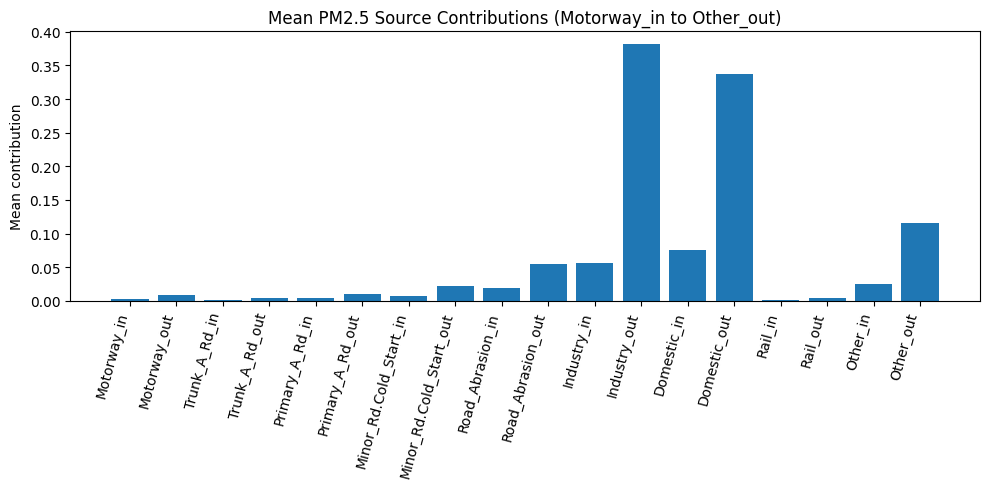

In [12]:
# =====================================================
# Figure A1: Mean PM2.5 Source Contributions (Motorway_in to Other_out)
# =====================================================

import os, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

POLLUTION_VARS = [
    "Motorway_in", "Motorway_out",
    "Trunk_A_Rd_in", "Trunk_A_Rd_out",
    "Primary_A_Rd_in", "Primary_A_Rd_out",
    "Minor_Rd.Cold_Start_in", "Minor_Rd.Cold_Start_out",
    "Road_Abrasion_in", "Road_Abrasion_out",
    "Industry_in", "Industry_out",
    "Domestic_in", "Domestic_out",
    "Rail_in", "Rail_out",
    "Other_in", "Other_out",
]

def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

def save_figure(fig_id: str, title: str) -> Path:
    f = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
    plt.savefig(f, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {fig_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, POLLUTION_VARS)

# Coerce to numeric
for c in POLLUTION_VARS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

fig_id = "Figure_A1"
title = "Mean PM2.5 Source Contributions Motorway_in to Other_out"

mean_values = df[POLLUTION_VARS].mean(numeric_only=True)

plt.figure(figsize=(10, 5))
plt.bar(mean_values.index, mean_values.values)
plt.xticks(rotation=75, ha="right")
plt.ylabel("Mean contribution")
plt.title("Mean PM2.5 Source Contributions (Motorway_in to Other_out)")
plt.tight_layout()

save_figure(fig_id, title)
plt.show()


###  Histogram of Total PM2.5 

[SAVED] outputs\figures\Figure_2_histogram_total_pm25.png


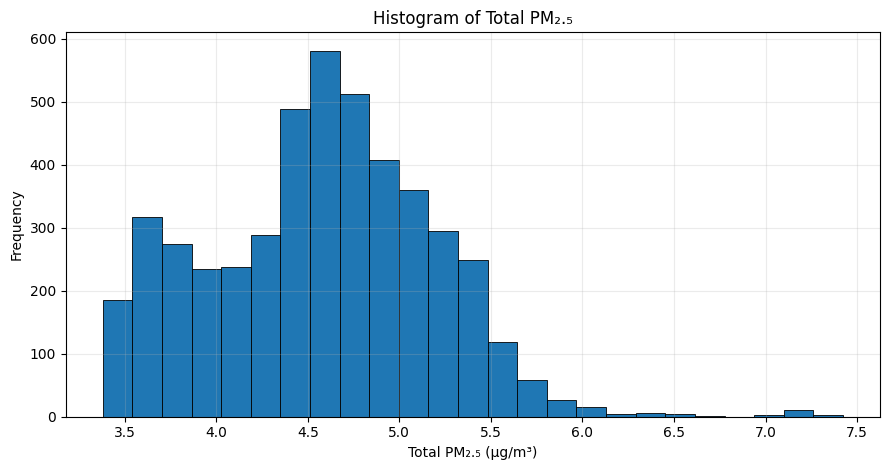

In [44]:
# =====================================================
# Histogram of Total PM2.5 
# =====================================================

import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# PATHS
# -------------------------
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

# -------------------------
# LOAD DATA
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]

# Ensure numeric
df["Total_PM25"] = pd.to_numeric(df["Total_PM25"], errors="coerce")
d = df.dropna(subset=["Total_PM25"]).copy()

# -------------------------
# PLOT (MATCH THESIS STYLE)
# -------------------------
fig_id = "Figure_2"
title = "Histogram of Total PM₂.₅"

plt.figure(figsize=(9, 4.8))

plt.hist(
    d["Total_PM25"],
    bins=25,                 
    color="#1f77b4",          # matplotlib default blue 
    edgecolor="black",
    linewidth=0.6
)

plt.title(title)
plt.xlabel("Total PM₂.₅ (µg/m³)")
plt.ylabel("Frequency")

plt.grid(True, linestyle="-", alpha=0.25)
plt.tight_layout()

out = OUT_FIGS / "Figure_2_histogram_total_pm25.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
print("[SAVED]", out)

plt.show()


### Figure A3: Boxplot of Total PM2.5 by Local Authority Code

[SAVED] Figure_A3: Boxplot of Total PM2.5 by Local Authority Code
 -> outputs\figures\Figure_A3_boxplot_of_total_pm25_by_local_authority_code.png


<Figure size 1000x500 with 0 Axes>

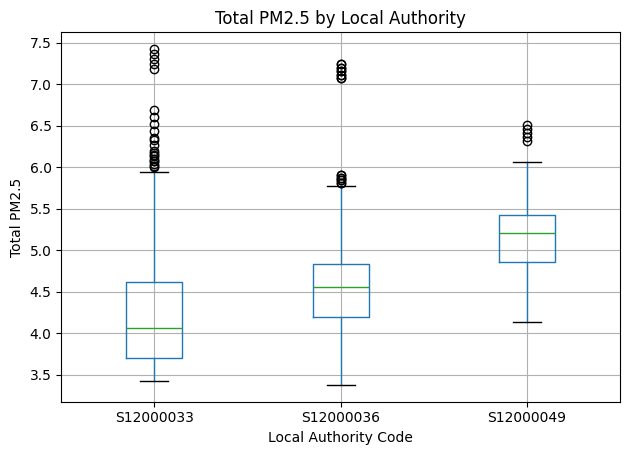

In [14]:
# =====================================================
# Figure A3: Boxplot of Total PM2.5 by Local Authority Code
# =====================================================

import os, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "Total_PM25"]

def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

def save_figure(fig_id: str, title: str) -> Path:
    f = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
    plt.savefig(f, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {fig_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

df["Total_PM25"] = pd.to_numeric(df["Total_PM25"], errors="coerce")

fig_id = "Figure_A3"
title = "Boxplot of Total PM2.5 by Local Authority Code"

plt.figure(figsize=(10, 5))
df.boxplot(column="Total_PM25", by="Local_Auth_Code")
plt.title("Total PM2.5 by Local Authority")
plt.suptitle("")
plt.xlabel("Local Authority Code")
plt.ylabel("Total PM2.5")
plt.tight_layout()

save_figure(fig_id, title)
plt.show()


### Objective 2 Base Frame: df2 used by Tables/Figures B*

In [16]:
# =====================================================
# Objective 2 Base Frame: df2 used by Tables/Figures B*
# =====================================================

import os, re
import pandas as pd

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"

REQUIRED = ["Total_PM25", "RatePer100000"]

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

df["Total_PM25"] = pd.to_numeric(df["Total_PM25"], errors="coerce")
df["RatePer100000"] = pd.to_numeric(df["RatePer100000"], errors="coerce")

df2 = df.dropna(subset=["Total_PM25", "RatePer100000"]).copy()
print("df2 shape:", df2.shape)
df2.head(5)


df2 shape: (4680, 33)


,Local_Auth_Code,x,y,geo_area,EU_zone_agglom,Total_PM25,Motorway_in,Motorway_out,Trunk_A_Rd_in,Trunk_A_Rd_out,...,Rail_out,Other_in,Other_out,PM_secondary,Residual.Salt,Point_Sources,Sex,AgeGroup,Pathogen,RatePer100000
0,S12000033,383500,815500,1,38,3.624074,0.0,0.0,0.0,0.003777,...,0.001013,0.002589,0.050993,2.405387,0.754099,0.016341,Female,<1 years,Adenovirus,7.535795
1,S12000033,384500,815500,1,38,3.741345,0.0,0.0,0.0,0.003913,...,0.001033,0.001642,0.057703,2.405387,0.859388,0.017382,Female,<1 years,Human metapneumovirus,0.000000
2,S12000033,385500,815500,1,38,3.761882,0.0,0.0,0.0,0.004522,...,0.001057,0.001723,0.068279,2.400255,0.854598,0.018405,Female,<1 years,Influenza - Type A (any subtype),0.000000
3,S12000033,383500,814500,1,38,3.709866,0.0,0.0,0.0,0.004628,...,0.000897,0.002731,0.052971,2.425729,0.756858,0.016789,Female,<1 years,Influenza - Type A (not subtyped),0.000000
4,S12000033,384500,814500,1,38,3.618867,0.0,0.0,0.0,0.004821,...,0.000948,0.002885,0.059846,2.425729,0.690853,0.018353,Female,<1 years,Influenza - Type A or B,0.000000


### Table B1: Correlation Between Total PM2.5 and Respiratory Rate by Local Authority

In [17]:
# =====================================================
# Table B1: Correlation Between Total PM2.5 and Respiratory Rate by Local Authority
# =====================================================

import os, re
from pathlib import Path
import numpy as np
import pandas as pd

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_TABLES = Path("outputs") / "tables"
OUT_TABLES.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "Total_PM25", "RatePer100000"]

def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

def save_table(df_table: pd.DataFrame, table_id: str, title: str) -> Path:
    f = OUT_TABLES / f"{table_id}_{slugify(title)}.csv"
    df_table.to_csv(f, index=False)
    print(f"[SAVED] {table_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

df["Total_PM25"] = pd.to_numeric(df["Total_PM25"], errors="coerce")
df["RatePer100000"] = pd.to_numeric(df["RatePer100000"], errors="coerce")

df2 = df.dropna(subset=["Total_PM25", "RatePer100000"]).copy()

def corr_pm25_rate(group: pd.DataFrame) -> float:
    g = group.dropna(subset=["Total_PM25", "RatePer100000"])
    if len(g) < 2:
        return np.nan
    return g["Total_PM25"].corr(g["RatePer100000"], method="pearson")

table_id = "Table_B1"
title = "Correlation Between Total PM2.5 and Respiratory Rate by Local Authority"

corr_by_la = (
    df2.groupby("Local_Auth_Code", dropna=False)
       .apply(corr_pm25_rate)
       .reset_index(name="Correlation_PM25_vs_Rate")
       .rename(columns={"Local_Auth_Code": "Local Authority Code"})
)

save_table(corr_by_la, table_id, title)

overall = df2["Total_PM25"].corr(df2["RatePer100000"])
print("Overall Pearson correlation:", round(overall, 4))

corr_by_la.head(10)


[SAVED] Table_B1: Correlation Between Total PM2.5 and Respiratory Rate by Local Authority
 -> outputs\tables\Table_B1_correlation_between_total_pm25_and_respiratory_rate_by_local_authority.csv
Overall Pearson correlation: -0.0614


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_12912\1942119787.py:72: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(corr_pm25_rate)


,Local Authority Code,Correlation_PM25_vs_Rate
0,S12000033,-0.114499
1,S12000036,-0.029303
2,S12000049,-0.245935


### Figure B3: Boxplot Respiratory Rate per 100,000 by Age Group

[SAVED] Figure_B3: Boxplot Respiratory Rate per 100,000 by Age Group
 -> outputs\figures\Figure_B3_boxplot_respiratory_rate_per_100000_by_age_group.png


<Figure size 700x400 with 0 Axes>

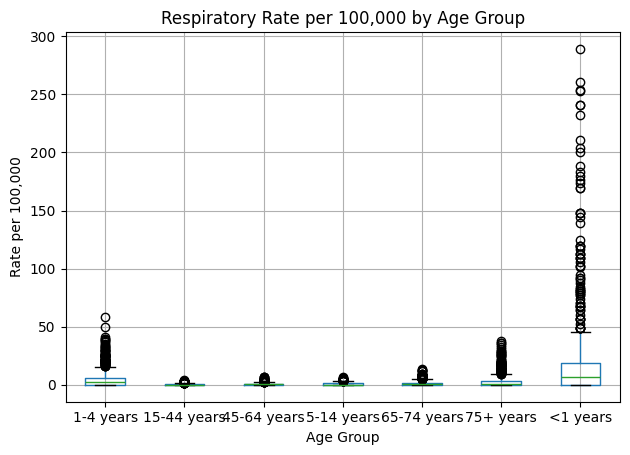

In [18]:
# =====================================================
# Figure B3: Boxplot Respiratory Rate per 100,000 by Age Group
# =====================================================

import os, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["RatePer100000", "AgeGroup"]

def slugify(text: str) -> str:
    s = text.lower().strip()
    s = re.sub(r"\s+", "_", s)
    s = re.sub(r"[^a-z0-9_]+", "", s)
    return s.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    rename_map, missing = {}, []
    for req in required:
        key = normalize(req)
        if key in lookup:
            rename_map[lookup[key]] = req
        else:
            missing.append(req)
    df = df.rename(columns=rename_map)
    if missing:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {missing}")
    return df

def save_figure(fig_id: str, title: str) -> Path:
    f = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
    plt.savefig(f, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {fig_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

df["RatePer100000"] = pd.to_numeric(df["RatePer100000"], errors="coerce")
df2 = df.dropna(subset=["RatePer100000", "AgeGroup"]).copy()

fig_id = "Figure_B3"
title = "Boxplot Respiratory Rate per 100,000 by Age Group"

plt.figure(figsize=(7, 4))
df2.boxplot(column="RatePer100000", by="AgeGroup")
plt.title("Respiratory Rate per 100,000 by Age Group")
plt.suptitle("")
plt.xlabel("Age Group")
plt.ylabel("Rate per 100,000")
plt.tight_layout()

save_figure(fig_id, title)
plt.show()


In [22]:
!pip install libpysal 

In [24]:
!conda install -y -c conda-forge libpysal

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\Lenovo\miniconda3\envs\myenv

  added / updated specs:
    - libpysal


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _libavif_api-1.3.0         |       h57928b3_2          10 KB  conda-forge
    aom-3.9.1                  |       he0c23c2_0         1.9 MB  conda-forge
    backports.zstd-1.3.0       |  py310h458dff3_0         186 KB  conda-forge
    beautifulsoup4-4.14.3      |     pyha770c72_0          88 KB  conda-forge
    blosc-1.21.6               |       h85f69ea_0          49 KB  conda-forge
    branca-0.8.2               |     pyhd8ed1ab_0          29 KB  conda-forge
    brotli-1.2.0               |       h2d644bc_1          20 KB  conda-forge
    brotli-bin-1.2.0           |       hfd05255_


CondaHTTPError: HTTP 000 CONNECTION FAILED for url <https://conda.anaconda.org/conda-forge/win-64/matplotlib-base-3.10.8-py310h0bdd906_0.conda>
Elapsed: -

An HTTP error occurred when trying to retrieve this URL.
HTTP errors are often intermittent, and a simple retry will get you on your way.

CondaHTTPError: HTTP 000 CONNECTION FAILED for url <https://conda.anaconda.org/conda-forge/win-64/matplotlib-base-3.10.8-py310h0bdd906_0.conda>
Elapsed: -

An HTTP error occurred when trying to retrieve this URL.
HTTP errors are often intermittent, and a simple retry will get you on your way.

CondaHTTPError: HTTP 000 CONNECTION FAILED for url <https://repo.anaconda.com/pkgs/main/win-64/libgdal-core-3.11.4-h9cea349_0.conda>
Elapsed: -

An HTTP error occurred when trying to retrieve this URL.
HTTP errors are often intermittent, and a simple retry will get you on your way.







proj-9.3.1           | 2.5 MB    | #######    |  71% 
icu-75.1             | 13.9 MB   | #########1 |  91% 






rav1e-0.7.1          | 3.9 MB    | #########8 |  98% 








proj-9.3.1           | 2.5 MB    | #######3   |  74% 






rav1e-0.7.1          | 3.9 MB    | #########8 |  99% 
icu-75.1             | 13.9 MB   | #########1 |  92% 






rav1e-0.7.1          | 3.9 MB    | ########## | 100% 






rav1e-0.7.1          | 3.9 MB    | ########## | 100% 
icu-75.1             | 13.9 MB   | #########2 |  92% 






rav1e-0.7.1          | 3.9 MB    | ########## | 100% 
icu-75.1             | 13.9 MB   | #########2 |  92% 








proj-9.3.1           | 2.5 MB    | ########6  |  86% 








proj-9.3.1           | 2.5 MB    | ########7  |  88% 
icu-75.1             | 13.9 MB   | #########2 |  93% 








proj-9.3.1           | 2.5 MB    | ########9  |  90% 









libpysal-4.13.0      | 2.1 MB    |            |   1% 








proj-9.3.1           | 2.5 MB    | #########9 |  99% 


### PM2.5 Hotspot z-Score Map (Gi*) (KNN on x,y)

In [26]:
# =====================================================
# PM2.5 Hotspot z-Score Map (Gi*) (KNN on x,y)
# =====================================================

import os, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- i have to import spatial hotspot libraries to perform the hotspot since GeoDa is not giving the expected results ---
try:
    from libpysal.weights import KNN
    from esda.getisord import G_Local
except ModuleNotFoundError:
    raise ModuleNotFoundError(
        "Missing packages for hotspot (Gi*) analysis.\n"
        "Install with ONE of these in a Jupyter cell:\n"
        "  !conda install -y -c conda-forge libpysal esda\n"
        "OR\n"
        "  !pip install libpysal esda\n"
        "Then restart kernel."
    )

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["x", "y", "Total_PM25"]

def slugify(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", "_", t)
    t = re.sub(r"[^a-z0-9_]+", "", t)
    return t.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

def save_fig(fig_id: str, title: str) -> Path:
    f = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
    plt.savefig(f, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {fig_id}: {title}\n -> {f}")
    return f

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "Total_PM25"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

d = df.dropna(subset=["x", "y", "Total_PM25"]).copy()
coords = list(zip(d["x"].to_numpy(), d["y"].to_numpy()))

# KNN weights (k=6 is a reasonable default for point data)
w = KNN.from_array(coords, k=6)
w.transform = "R"

# Gi* local statistic
g = G_Local(d["Total_PM25"].to_numpy(), w, star=True)
d["GiZ_PM25"] = g.Zs
d["GiP_PM25"] = g.p_sim

# Classify hotspots/coldspots at 5% significance
d["Cluster_PM25"] = np.select(
    [
        (d["GiZ_PM25"] > 0) & (d["GiP_PM25"] <= 0.05),
        (d["GiZ_PM25"] < 0) & (d["GiP_PM25"] <= 0.05),
    ],
    ["Hotspot (p≤0.05)", "Coldspot (p≤0.05)"],
    default="Not significant"
)

# Plot
fig_id = "Figure_HS_PM25"
title = "PM2.5 Hotspot Z-Score Map (Getis-Ord Gi*)"

plt.figure(figsize=(7, 6))
for cat in ["Hotspot (p≤0.05)", "Coldspot (p≤0.05)", "Not significant"]:
    sub = d[d["Cluster_PM25"] == cat]
    plt.scatter(sub["x"], sub["y"], s=14, label=cat)

plt.title(title)
plt.xlabel("x (Easting)")
plt.ylabel("y (Northing)")
plt.legend()
plt.tight_layout()

save_fig(fig_id, title)
plt.show()

d[["GiZ_PM25","GiP_PM25","Cluster_PM25"]].head(10)


ModuleNotFoundError: Missing packages for hotspot (Gi*) analysis.
Install with ONE of these in a Jupyter cell:
  !conda install -y -c conda-forge libpysal esda
OR
  !pip install libpysal esda
Then restart kernel.

In [27]:
 !pip install libpysal esda

In [28]:
!conda install -y -c conda-forge esda libpysal

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: C:\Users\Lenovo\miniconda3\envs\myenv

  added / updated specs:
    - esda
    - libpysal


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _libavif_api-1.3.0         |       h57928b3_2          10 KB  conda-forge
    backports.zstd-1.3.0       |  py310h458dff3_0         186 KB  conda-forge
    beautifulsoup4-4.14.3      |     pyha770c72_0          88 KB  conda-forge
    blosc-1.21.6               |       h85f69ea_0          49 KB  conda-forge
    branca-0.8.2               |     pyhd8ed1ab_0          29 KB  conda-forge
    brotli-1.2.0               |       h2d644bc_1          20 KB  conda-forge
    brotli-bin-1.2.0           |       hfd05255_1          22 KB  conda-forge
    brotli-python-1.2.0        |  py3

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'SSLError(1, '[SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2657)')': /pkgs/main/noarch/repodata.json.zst

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'SSLError(1, '[SSL: SSLV3_ALERT_BAD_RECORD_MAC] sslv3 alert bad record mac (_ssl.c:2657)')': /pkgs/main/win-64/libgdal-core-3.11.4-h9cea349_0.conda

Retrying (Retry(total=2, connect=None, read=None, redirect=None, status=None)) after connection broken by 'SSLError(SSLError(1, '[SSL: DECRYPTION_FAILED_OR_BAD_RECORD_MAC] decryption failed or bad record mac (_ssl.c:1032)'))': /pkgs/main/win-64/libglib-2.84.4-hfaec014_0.conda

WARNING conda.gateways.disk.delete:unlink_or_rename_to_trash(184): Could not remove or rename C:\Users\Lenovo\miniconda3\envs\myenv\Lib\site-packages\matplotlib\mpl-data\fonts\ttf\DejaVuSans.ttf.  Please remove this file manually (














pyogrio-0.11.1       | 766 KB    |            |   0% 

















pillow-12.0.0        | 742 KB    |            |   0% 


















krb5-1.21.3          | 695 KB    |            |   0% 



















 ... (more hidden) ...



svt-av1-3.1.2        | 1.8 MB    | ####       |  40% 



svt-av1-3.1.2        | 1.8 MB    | ####3      |  44% 



svt-av1-3.1.2        | 1.8 MB    | ####7      |  47% 



svt-av1-3.1.2        | 1.8 MB    | #####1     |  51% 



svt-av1-3.1.2        | 1.8 MB    | #####7     |  57% 



svt-av1-3.1.2        | 1.8 MB    | ######     |  61% 

matplotlib-base-3.10 | 6.8 MB    |            |   0% 

matplotlib-base-3.10 | 6.8 MB    | 1          |   1% 

matplotlib-base-3.10 | 6.8 MB    | 1          |   2% 

matplotlib-base-3.10 | 6.8 MB    | 2          |   3% 

matplotlib-base-3.10 | 6.8 MB    | 3          |   3% 

matplotlib-base-3.10 | 6.8 MB    | 3          |   4% 

matplotlib-base-3.10 | 6.8 MB    | 5          |   6% 

matplotlib-base-3.10

### PM2.5 Hotspot Z-Score Map (Gi* z-scores) — KNN on x,y)

[SAVED] outputs\figures\Figure_HS_PM25_pm25_hotspot_z_score_map.png


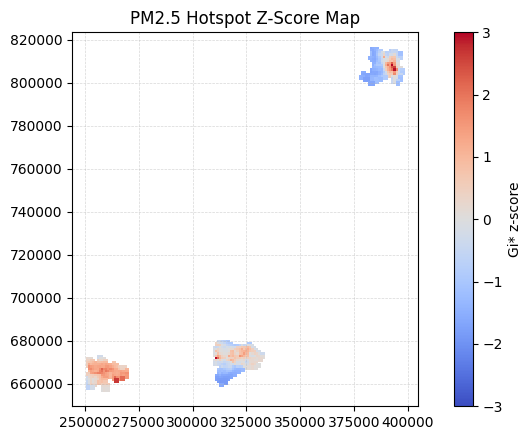

In [31]:
# =====================================================
# PM2.5 Hotspot Z-Score Map (Gi* z-scores) — KNN on x,y)
# =====================================================

import os, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Spatial Gi* packages
from libpysal.weights import KNN
from esda.getisord import G_Local

# -------------------------
# PATHS
# -------------------------
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

# -------------------------
# REQUIRED COLUMNS
# -------------------------
REQUIRED = ["x", "y", "Total_PM25"]

# -------------------------
# HELPERS (robust column matching)
# -------------------------
def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

# -------------------------
# LOAD DATA
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "Total_PM25"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

d = df.dropna(subset=["x", "y", "Total_PM25"]).copy()

# -------------------------
# Gi* (Getis-Ord) Z-SCORES
# -------------------------
coords = np.column_stack([d["x"].to_numpy(), d["y"].to_numpy()])

# Choose k (k=6 is a common default)
K = 6
w = KNN.from_array(coords, k=K)
w.transform = "R"

g = G_Local(d["Total_PM25"].to_numpy(), w, star=True)
d["GiZ_PM25"] = g.Zs

# -------------------------
# PLOT (match thesis style)
# -------------------------
fig_id = "Figure_HS_PM25"
title = "PM2.5 Hotspot Z-Score Map"

plt.figure(figsize=(7.5, 4.5))
ax = plt.gca()

sc = ax.scatter(
    d["x"], d["y"],
    c=d["GiZ_PM25"],
    cmap="coolwarm",
    vmin=-3, vmax=3,
    s=12, marker="s",  # pixel-like squares
    linewidths=0
)

ax.set_title(title)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_aspect("equal", adjustable="box")

cbar = plt.colorbar(sc)
cbar.set_label("Gi* z-score")

plt.tight_layout()

out_file = OUT_FIGS / f"{fig_id}_pm25_hotspot_z_score_map.png"
plt.savefig(out_file, dpi=300, bbox_inches="tight")
print("[SAVED]", out_file)

plt.show()


### Respiratory Rate Hotspot Z-Score Map (Gi* z-scores)

[SAVED] outputs\figures\Figure_HS_Rate_respiratory_rate_hotspot_z_score_map.png


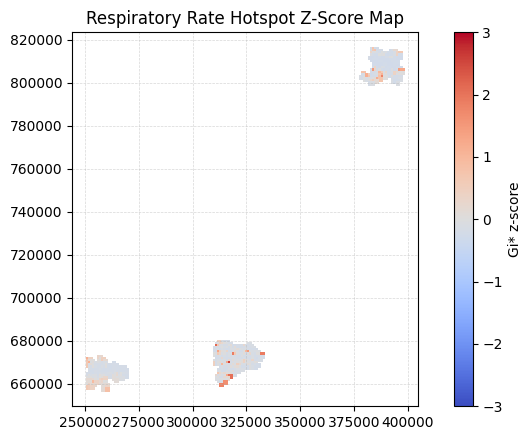

In [30]:
# =====================================================
# Respiratory Rate Hotspot Z-Score Map (Gi* z-scores) 
# =====================================================

import os, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Spatial Gi* packages
from libpysal.weights import KNN
from esda.getisord import G_Local

# -------------------------
# PATHS
# -------------------------
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

# -------------------------
# REQUIRED COLUMNS
# -------------------------
REQUIRED = ["x", "y", "RatePer100000"]

# -------------------------
# HELPERS (robust column matching)
# -------------------------
def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

# -------------------------
# LOAD DATA
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "RatePer100000"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

d = df.dropna(subset=["x", "y", "RatePer100000"]).copy()

# -------------------------
# Gi* (Getis-Ord) Z-SCORES
# -------------------------
coords = np.column_stack([d["x"].to_numpy(), d["y"].to_numpy()])

# Choose k to match your thesis output (k=6 is a common default; change if needed)
K = 6
w = KNN.from_array(coords, k=K)
w.transform = "R"

g = G_Local(d["RatePer100000"].to_numpy(), w, star=True)
d["GiZ_Rate"] = g.Zs

# -------------------------
# PLOT (match thesis style)
# -------------------------
fig_id = "Figure_HS_Rate"
title = "Respiratory Rate Hotspot Z-Score Map"

plt.figure(figsize=(7.5, 4.5))  # 
ax = plt.gca()

# Continuous colour (diverging) with fixed range -3 to +3 
sc = ax.scatter(
    d["x"], d["y"],
    c=d["GiZ_Rate"],
    cmap="coolwarm",
    vmin=-3, vmax=3,
    s=12, marker="s",  # small “pixel-like” squares 
    linewidths=0
)

ax.set_title(title)
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.5)
ax.set_aspect("equal", adjustable="box")  # preserves spatial proportions

cbar = plt.colorbar(sc)
cbar.set_label("Gi* z-score")

plt.tight_layout()

out_file = OUT_FIGS / f"{fig_id}_respiratory_rate_hotspot_z_score_map.png"
plt.savefig(out_file, dpi=300, bbox_inches="tight")
print("[SAVED]", out_file)

plt.show()


### Model Performance Metrics — (Linear + Random Forest)

In [32]:
# =====================================================
# Model Performance Metrics — (Linear + Random Forest)
# =====================================================

import os, re
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"

REQUIRED = ["Local_Auth_Code", "x", "y", "Total_PM25", "Sex", "AgeGroup", "Pathogen", "RatePer100000"]

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "Total_PM25", "RatePer100000"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

data = df[REQUIRED].dropna().copy()
data["log_rate"] = np.log1p(data["RatePer100000"])

X = data[["x", "y", "Total_PM25", "Local_Auth_Code", "Sex", "AgeGroup", "Pathogen"]]
X = pd.get_dummies(X, drop_first=True)
y = data["log_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Linear Regression
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

# Random Forest
rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

def metrics(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred, squared=False),
        "MAE": mean_absolute_error(y_true, y_pred)
    }

m_lin = metrics(y_test, pred_lin)
m_rf  = metrics(y_test, pred_rf)

print("Linear Regression:", {k: round(v, 4) for k, v in m_lin.items()})
print("Random Forest    :", {k: round(v, 4) for k, v in m_rf.items()})

# Keep these for use in the future
m_lin, m_rf


TypeError: got an unexpected keyword argument 'squared'

[SAVED] outputs\figures\Figure_Observed_vs_Predicted_LogRate_LinearRegression_observed_vs_predicted_log_rate__linear_regression.png


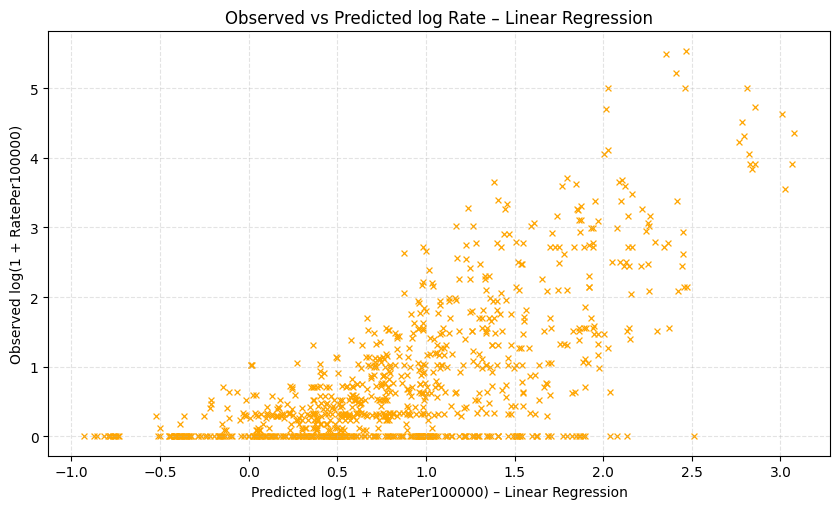

In [34]:
# =====================================================
# Observed vs Predicted log Rate – Linear Regression 
# =====================================================

import os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# -------------------------
# PATHS
# -------------------------
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "x", "y", "Total_PM25", "Sex", "AgeGroup", "Pathogen", "RatePer100000"]

# -------------------------
# HELPERS
# -------------------------
def slugify(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", "_", t)
    t = re.sub(r"[^a-z0-9_]+", "", t)
    return t.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

# -------------------------
# LOAD + PREP
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "Total_PM25", "RatePer100000"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

data = df[REQUIRED].dropna().copy()
data["log_rate"] = np.log1p(data["RatePer100000"])

X = data[["x", "y", "Total_PM25", "Local_Auth_Code", "Sex", "AgeGroup", "Pathogen"]]
X = pd.get_dummies(X, drop_first=True)
y = data["log_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# LINEAR REGRESSION
# -------------------------
lin = LinearRegression()
lin.fit(X_train, y_train)
pred = lin.predict(X_test)

# -------------------------
# PLOT (MATCH THESIS STYLE)
# -------------------------
fig_id = "Figure_Observed_vs_Predicted_LogRate_LinearRegression"
title = "Observed vs Predicted log Rate – Linear Regression"

plt.figure(figsize=(8.5, 5.2))
plt.scatter(
    pred, y_test,
    marker="x",
    s=18,
    linewidths=0.9,
    c="orange"
)

plt.title(title)
plt.xlabel("Predicted log(1 + RatePer100000) – Linear Regression")
plt.ylabel("Observed log(1 + RatePer100000)")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()

out_file = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
plt.savefig(out_file, dpi=300, bbox_inches="tight")
print("[SAVED]", out_file)

plt.show()


### Observed vs Predicted log Rate – Random Forest

[SAVED] outputs\figures\Figure_Observed_vs_Predicted_LogRate_RandomForest_observed_vs_predicted_log_rate__random_forest.png


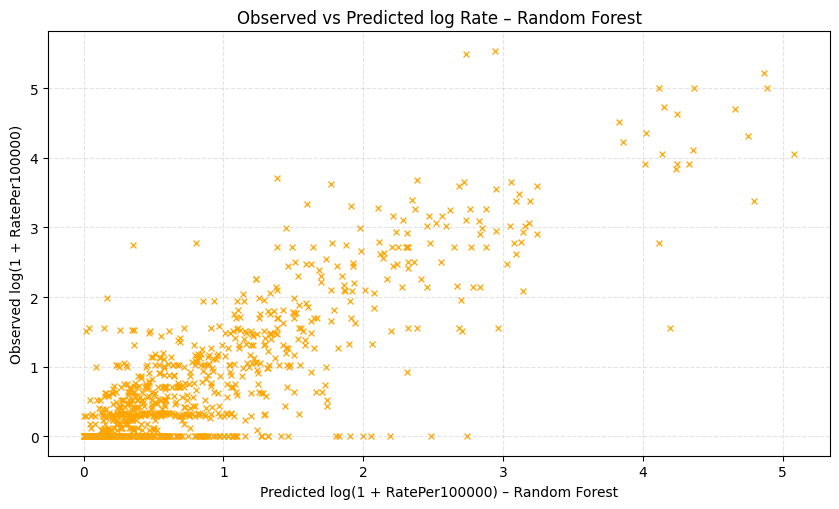

In [36]:
# =====================================================
# Observed vs Predicted log Rate – Random Forest 
# =====================================================

import os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# PATHS
# -------------------------
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "x", "y", "Total_PM25", "Sex", "AgeGroup", "Pathogen", "RatePer100000"]

# -------------------------
# HELPERS
# -------------------------
def slugify(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", "_", t)
    t = re.sub(r"[^a-z0-9_]+", "", t)
    return t.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

# -------------------------
# LOAD + PREP
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "Total_PM25", "RatePer100000"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

data = df[REQUIRED].dropna().copy()
data["log_rate"] = np.log1p(data["RatePer100000"])

X = data[["x", "y", "Total_PM25", "Local_Auth_Code", "Sex", "AgeGroup", "Pathogen"]]
X = pd.get_dummies(X, drop_first=True)
y = data["log_rate"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# RANDOM FOREST
# -------------------------
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

# -------------------------
# PLOT (MATCH THESIS STYLE)
# -------------------------
fig_id = "Figure_Observed_vs_Predicted_LogRate_RandomForest"
title = "Observed vs Predicted log Rate – Random Forest"

plt.figure(figsize=(8.5, 5.2))
plt.scatter(
    pred, y_test,
    marker="x",
    s=18,
    linewidths=0.9,
    c="orange"
)

plt.title(title)
plt.xlabel("Predicted log(1 + RatePer100000) – Random Forest")
plt.ylabel("Observed log(1 + RatePer100000)")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()

out_file = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
plt.savefig(out_file, dpi=300, bbox_inches="tight")
print("[SAVED]", out_file)

plt.show()


### Random Forest Residuals Histogram 

[SAVED] outputs\figures\Figure_RF_Residuals_Histogram_random_forest_residuals_histogram.png


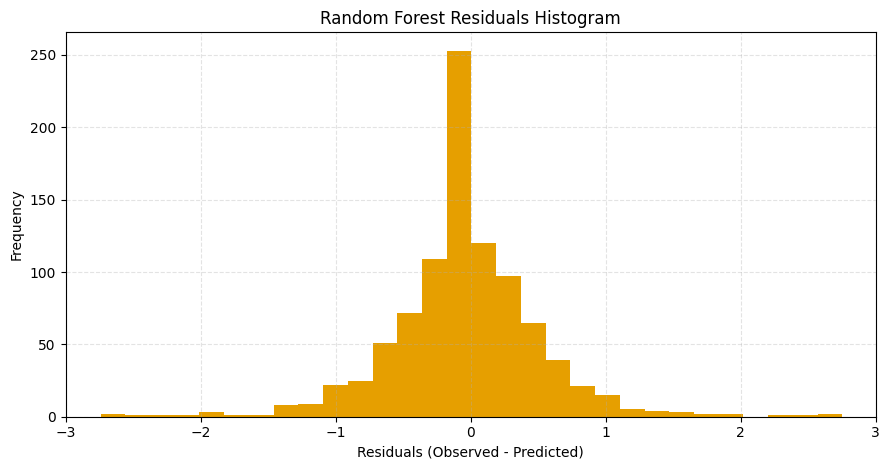

In [38]:
# =====================================================
# Random Forest Residuals Histogram 
# =====================================================

import os, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "x", "y", "Total_PM25", "Sex", "AgeGroup", "Pathogen", "RatePer100000"]

def slugify(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", "_", t)
    t = re.sub(r"[^a-z0-9_]+", "", t)
    return t.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

# ---- Load ----
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "Total_PM25", "RatePer100000"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

data = df[REQUIRED].dropna().copy()
data["log_rate"] = np.log1p(data["RatePer100000"])

X = data[["x", "y", "Total_PM25", "Local_Auth_Code", "Sex", "AgeGroup", "Pathogen"]]
X = pd.get_dummies(X, drop_first=True)
y = data["log_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

resid = (y_test - pred)

# ---- Plot (thesis-style) ----
fig_id = "Figure_RF_Residuals_Histogram"
title = "Random Forest Residuals Histogram"

plt.figure(figsize=(9, 4.8))
plt.hist(resid, bins=30, color="#E69F00")  
plt.title(title)
plt.xlabel("Residuals (Observed - Predicted)")
plt.ylabel("Frequency")
plt.grid(True, linestyle="--", alpha=0.35)

# match thesis x-range feel
plt.xlim(-3, 3)

plt.tight_layout()
out = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
print("[SAVED]", out)
plt.show()



### Total PM2.5 vs Respiratory Rate (per 100,000) 

[SAVED] outputs\figures\Figure_PM25_vs_Rate_All_total_pm_vs_respiratory_rate_per_100000.png


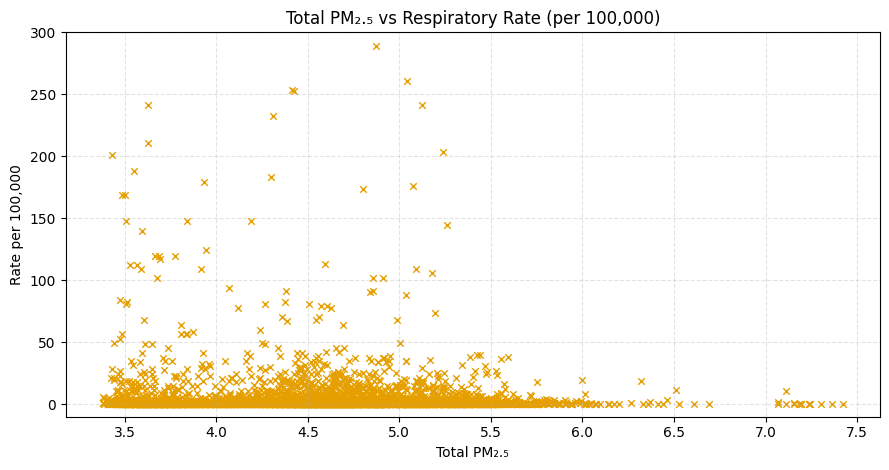

In [39]:
# =====================================================
# Total PM2.5 vs Respiratory Rate (per 100,000) 
# =====================================================

import os, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Total_PM25", "RatePer100000"]

def slugify(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", "_", t)
    t = re.sub(r"[^a-z0-9_]+", "", t)
    return t.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

df["Total_PM25"] = pd.to_numeric(df["Total_PM25"], errors="coerce")
df["RatePer100000"] = pd.to_numeric(df["RatePer100000"], errors="coerce")

d = df.dropna(subset=["Total_PM25", "RatePer100000"]).copy()

fig_id = "Figure_PM25_vs_Rate_All"
title = "Total PM₂.₅ vs Respiratory Rate (per 100,000)"

plt.figure(figsize=(9, 4.8))
plt.scatter(
    d["Total_PM25"], d["RatePer100000"],
    marker="x", s=22, linewidths=1.0, c="#E69F00"
)

plt.title(title)
plt.xlabel("Total PM₂.₅")
plt.ylabel("Rate per 100,000")
plt.grid(True, linestyle="--", alpha=0.35)

# match thesis y-range look
plt.ylim(-10, 300)

plt.tight_layout()
out = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
print("[SAVED]", out)
plt.show()


### Total PM2.5 vs Rate per 100,000 by Local Authority (3-city)

[SAVED] outputs\figures\Figure_PM25_vs_Rate_By_LA_total_pm_vs_rate_per_100000_by_local_authority.png


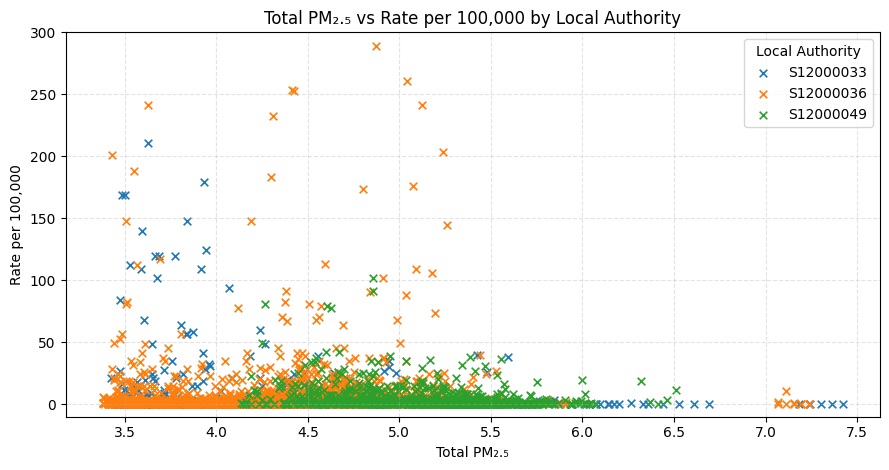

In [40]:
# =====================================================
# Total PM2.5 vs Rate per 100,000 by Local Authority (3-city) 
# =====================================================

import os, re
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_FIGS.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "Total_PM25", "RatePer100000"]

LA_CODES = ["S12000033", "S12000036", "S12000049"]  # Glasgow, Edinburgh, Aberdeen

def slugify(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", "_", t)
    t = re.sub(r"[^a-z0-9_]+", "", t)
    return t.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

df["Total_PM25"] = pd.to_numeric(df["Total_PM25"], errors="coerce")
df["RatePer100000"] = pd.to_numeric(df["RatePer100000"], errors="coerce")

d = df.dropna(subset=["Local_Auth_Code", "Total_PM25", "RatePer100000"]).copy()
d = d[d["Local_Auth_Code"].isin(LA_CODES)].copy()

fig_id = "Figure_PM25_vs_Rate_By_LA"
title = "Total PM₂.₅ vs Rate per 100,000 by Local Authority"

plt.figure(figsize=(9, 4.8))

for code in LA_CODES:
    sub = d[d["Local_Auth_Code"] == code]
    plt.scatter(
        sub["Total_PM25"], sub["RatePer100000"],
        marker="x", s=30, linewidths=1.2, label=code
    )

plt.title(title)
plt.xlabel("Total PM₂.₅")
plt.ylabel("Rate per 100,000")
plt.grid(True, linestyle="--", alpha=0.35)
plt.ylim(-10, 300)

leg = plt.legend(title="Local Authority", loc="upper right")
plt.tight_layout()

out = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
print("[SAVED]", out)
plt.show()


### Random Forest Dominant Predictors (Horizontal Bar)

[SAVED] Figure_RF_Dominant_Predictors: Random Forest Dominant Predictors (Improved Horizontal Bar Chart)
 -> outputs\figures\Figure_RF_Dominant_Predictors_random_forest_dominant_predictors_improved_horizontal_bar_chart.png


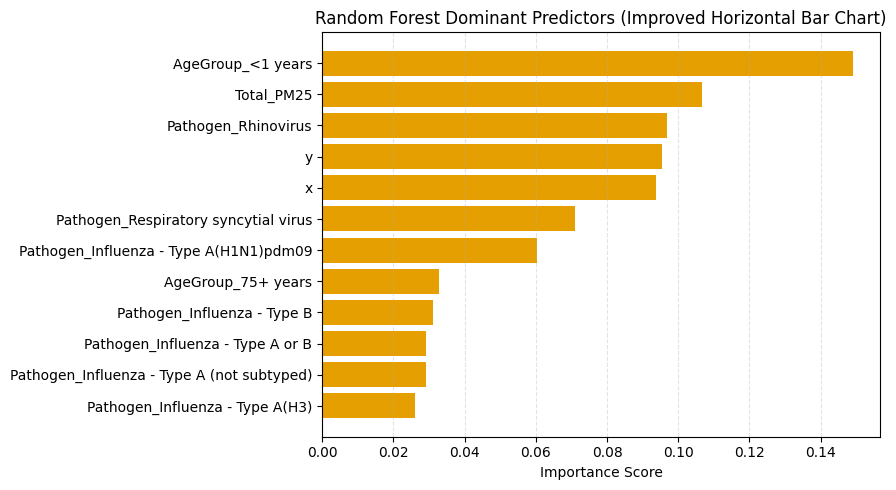

,Predictor,Importance
0,AgeGroup_<1 years,0.149211
1,Total_PM25,0.106773
2,Pathogen_Rhinovirus,0.096854
3,y,0.095321
4,x,0.093851
5,Pathogen_Respiratory syncytial virus,0.071069
6,Pathogen_Influenza - Type A(H1N1)pdm09,0.060254
7,AgeGroup_75+ years,0.032806
8,Pathogen_Influenza - Type B,0.031003
9,Pathogen_Influenza - Type A or B,0.029156


In [43]:
# =====================================================
# Random Forest Dominant Predictors (Horizontal Bar) 
# =====================================================

import os, re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# -------------------------
# PATHS
# -------------------------
DATA_PATH = r"C:\Users\Lenovo\Merged_file_pollution25 original data.csv"
OUT_FIGS = Path("outputs") / "figures"
OUT_TABLES = Path("outputs") / "tables"
OUT_FIGS.mkdir(parents=True, exist_ok=True)
OUT_TABLES.mkdir(parents=True, exist_ok=True)

REQUIRED = ["Local_Auth_Code", "x", "y", "Total_PM25", "Sex", "AgeGroup", "Pathogen", "RatePer100000"]

# -------------------------
# HELPERS
# -------------------------
def slugify(t: str) -> str:
    t = t.lower().strip()
    t = re.sub(r"\s+", "_", t)
    t = re.sub(r"[^a-z0-9_]+", "", t)
    return t.strip("_")

def normalize(name: str) -> str:
    s = name.strip().lower().replace(" ", "").replace(".", "_")
    s = re.sub(r"[^a-z0-9_]", "", s)
    s = re.sub(r"_+", "_", s)
    return s

def auto_rename(df: pd.DataFrame, required: list[str]) -> pd.DataFrame:
    lookup = {normalize(c): c for c in df.columns}
    ren, miss = {}, []
    for req in required:
        k = normalize(req)
        if k in lookup:
            ren[lookup[k]] = req
        else:
            miss.append(req)
    df = df.rename(columns=ren)
    if miss:
        print("Columns found:", df.columns.tolist())
        raise ValueError(f"Missing required columns: {miss}")
    return df

def save_fig(fig_id: str, title: str) -> Path:
    f = OUT_FIGS / f"{fig_id}_{slugify(title)}.png"
    plt.savefig(f, dpi=300, bbox_inches="tight")
    print(f"[SAVED] {fig_id}: {title}\n -> {f}")
    return f

# -------------------------
# LOAD + PREP
# -------------------------
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(DATA_PATH)

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]
df = auto_rename(df, REQUIRED)

for c in ["x", "y", "Total_PM25", "RatePer100000"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

data = df[REQUIRED].dropna().copy()
data["log_rate"] = np.log1p(data["RatePer100000"])

X = data[["x", "y", "Total_PM25", "Local_Auth_Code", "Sex", "AgeGroup", "Pathogen"]]
X = pd.get_dummies(X, drop_first=True)
y = data["log_rate"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------
# RANDOM FOREST
# -------------------------
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Pick top N (thesis screenshot shows about ~12)
TOP_N = 12
top = importances.head(TOP_N).sort_values(ascending=True)  # ascending for horizontal bar plot

# Save the top predictors table too (optional but useful)
top_table = top.sort_values(ascending=False).reset_index()
top_table.columns = ["Predictor", "Importance"]
top_table.to_csv(OUT_TABLES / "Table_RF_Dominant_Predictors.csv", index=False)

# -------------------------
# PLOT (MATCH THESIS STYLE)
# -------------------------
fig_id = "Figure_RF_Dominant_Predictors"
title = "Random Forest Dominant Predictors (Improved Horizontal Bar Chart)"

plt.figure(figsize=(9, 5))
plt.barh(top.index, top.values, color="#E69F00")  # use orange colour
plt.xlabel("Importance Score")
plt.title(title)
plt.grid(True, axis="x", linestyle="--", alpha=0.35)
plt.tight_layout()

save_fig(fig_id, title)
plt.show()

top_table.head(12)

